<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%205/regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 — Regularization: Seeing Overfitting and Fixing It

**Goal:** Make overfitting *visible*, then defeat it with dropout and weight decay.

A network with lots of capacity trained on little data will **memorize** the training set — driving training loss to near zero while performing poorly on data it hasn't seen. This gap between training and validation performance is overfitting, and regularization is the set of techniques that closes it.

**The experiment:** deliberately overfit a big network on just 500 MNIST images, watch train and validation loss diverge, then add regularization and watch the gap shrink.

| Technique | What it does | How we apply it |
|---|---|---|
| **Dropout** | randomly zeros neurons during training | `nn.Dropout(p)` between layers |
| **Weight decay (L2)** | penalizes large weights | `weight_decay=` in the optimizer |

---

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms

%matplotlib inline

## 1. Load MNIST

We load the full dataset, but the key move for this experiment is in the next cell: we'll train on only a **tiny slice** of it, which is what forces overfitting.

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

train = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Full test set for validation
test_dataloader = DataLoader(test, batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.26MB/s]


## 2. The Key Ingredient — A Tiny Training Set

Overfitting is most dramatic when a high-capacity model meets very little data. By training on just **500 images**, we give the network far more parameters than it needs to memorize the data — so it will. This is the setup that makes the train/validation gap appear.

In [ ]:
small_train = Subset(train, range(500))
small_dataloader = DataLoader(small_train, batch_size=64, shuffle=True)

print(f"Training on {len(small_train)} images (vs {len(train)} available)")

Training on 500 images (vs 60000 available)


## 3. Two Models — Plain vs Regularized

Same architecture (784 → 256 → 256 → 10), one difference: `DropoutNet` inserts `nn.Dropout(0.5)` after each hidden layer. Dropout randomly zeros half the neurons on each forward pass during training, forcing the network to spread its representation across many neurons instead of over-relying on a few — which fights memorization.

In [ ]:
class PlainNet(nn.Module):
    """No regularization — will overfit hard on 500 images."""
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.layers(x)


class DropoutNet(nn.Module):
    """Same net + dropout after each hidden layer."""
    def __init__(self, p=0.5):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(), nn.Dropout(p),
            nn.Linear(256, 256), nn.ReLU(), nn.Dropout(p),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.layers(x)

## 4. A Reusable Training Function

The critical design choice: **one function that trains a fresh model and records train AND validation loss every epoch, in the same loop.** Measuring both together, epoch by epoch, is what lets us see them diverge.

Two details that matter:
- **`model.train()` vs `model.eval()`** — toggles dropout ON for training, OFF for validation. Dropout must be disabled at test time so the full network is used. PyTorch handles the switch when you set the mode.
- **`weight_decay`** — passed to the optimizer, this adds L2 regularization (penalizing large weights) for free.

Returning fresh histories each call means every experiment is a clean, independent comparison.

In [ ]:
def run_experiment(model, epochs=100, lr=0.15, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # --- TRAIN (dropout ON) ---
        model.train()
        running_train = 0.0
        for images, labels in small_dataloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train += loss.item()
        train_losses.append(running_train / len(small_dataloader))

        # --- VALIDATE (dropout OFF) ---
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for images, labels in test_dataloader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val += loss.item()
        val_losses.append(running_val / len(test_dataloader))

        if epoch % 10 == 0:
            print(f"Epoch {epoch+1:3d} — train: {train_losses[-1]:.4f}  val: {val_losses[-1]:.4f}")

    return train_losses, val_losses

## 5. Experiment A — Overfit With No Regularization

Train the plain network. Watch what happens: **training loss dives toward zero** (the model memorizes the 500 images), while **validation loss bottoms out and then creeps back up**. That upward turn in validation loss is the signature of overfitting — the model is getting better at the training data and *worse* at everything else.

In [ ]:
torch.manual_seed(0)
plain_train, plain_val = run_experiment(PlainNet(), epochs=100)

Epoch   1 — train: 2.2889  val: 2.2665
Epoch  11 — train: 0.4199  val: 0.7294
Epoch  21 — train: 0.1171  val: 0.5411
Epoch  31 — train: 0.0416  val: 0.5598
Epoch  41 — train: 0.0211  val: 0.6030
Epoch  51 — train: 0.0133  val: 0.6350
Epoch  61 — train: 0.0094  val: 0.6589
Epoch  71 — train: 0.0072  val: 0.6736
Epoch  81 — train: 0.0057  val: 0.6929
Epoch  91 — train: 0.0047  val: 0.7048


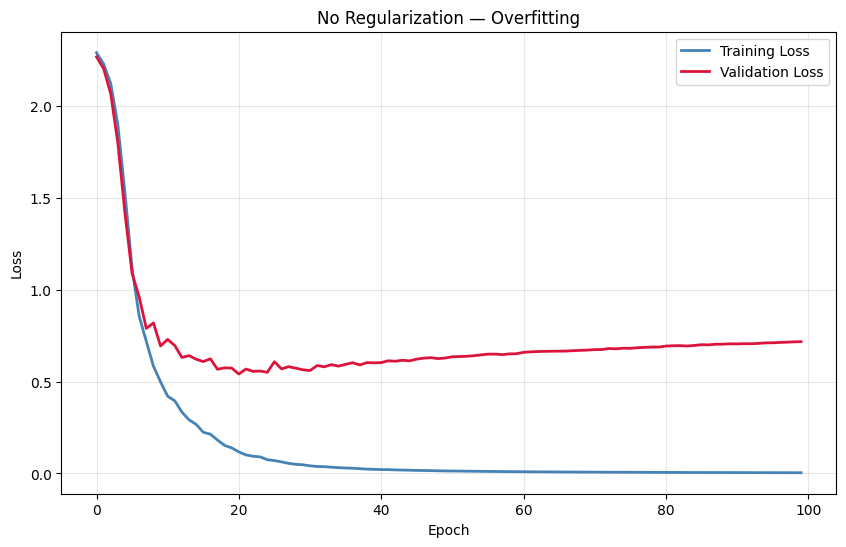

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(plain_train, label='Training Loss', color='steelblue', lw=2)
plt.plot(plain_val,   label='Validation Loss', color='crimson', lw=2)
plt.title('No Regularization — Overfitting')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.show()



---
## 6. Experiment B — Add Dropout

Same tiny dataset, same architecture, but now with `nn.Dropout(0.5)` after each hidden layer. Dropout should keep the training loss from collapsing all the way to zero (the network can't memorize as easily) and keep validation loss lower — a smaller gap.

In [ ]:
torch.manual_seed(0)
drop_train, drop_val = run_experiment(DropoutNet(p=0.5), epochs=100)

Epoch   1 — train: 2.2941  val: 2.2739
Epoch  11 — train: 0.7229  val: 0.8131
Epoch  21 — train: 0.3011  val: 0.5748
Epoch  31 — train: 0.1722  val: 0.5503
Epoch  41 — train: 0.1023  val: 0.5441
Epoch  51 — train: 0.0651  val: 0.5695
Epoch  61 — train: 0.0635  val: 0.5999
Epoch  71 — train: 0.0384  val: 0.6248
Epoch  81 — train: 0.0244  val: 0.6245
Epoch  91 — train: 0.0197  val: 0.6534


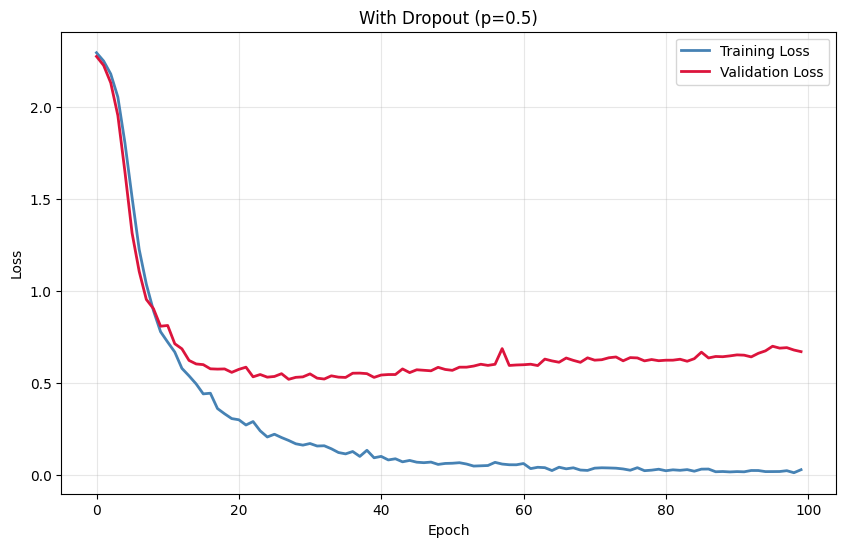

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(drop_train, label='Training Loss', color='steelblue', lw=2)
plt.plot(drop_val,   label='Validation Loss', color='crimson', lw=2)
plt.title('With Dropout (p=0.5)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---
## 7. Experiment C — Weight Decay (L2)

L2 regularization adds a penalty proportional to the sum of squared weights, discouraging large weights and favoring simpler, smoother functions. In PyTorch it's a single argument: `weight_decay`. Here we apply it to the plain network.

In [ ]:
torch.manual_seed(0)
wd_train, wd_val = run_experiment(PlainNet(), epochs=100, weight_decay=1e-3)

Epoch   1 — train: 2.2889  val: 2.2666
Epoch  11 — train: 0.4266  val: 0.7346
Epoch  21 — train: 0.1240  val: 0.5398
Epoch  31 — train: 0.0468  val: 0.5516
Epoch  41 — train: 0.0253  val: 0.5867
Epoch  51 — train: 0.0171  val: 0.6106
Epoch  61 — train: 0.0130  val: 0.6273
Epoch  71 — train: 0.0107  val: 0.6317
Epoch  81 — train: 0.0092  val: 0.6440
Epoch  91 — train: 0.0082  val: 0.6448


## 8. Compare All Three — Validation Loss

The clearest way to see regularization working: plot the **validation loss** of all three side by side. The plain model's val loss should be highest (worst generalization); dropout and weight decay should both pull it lower.

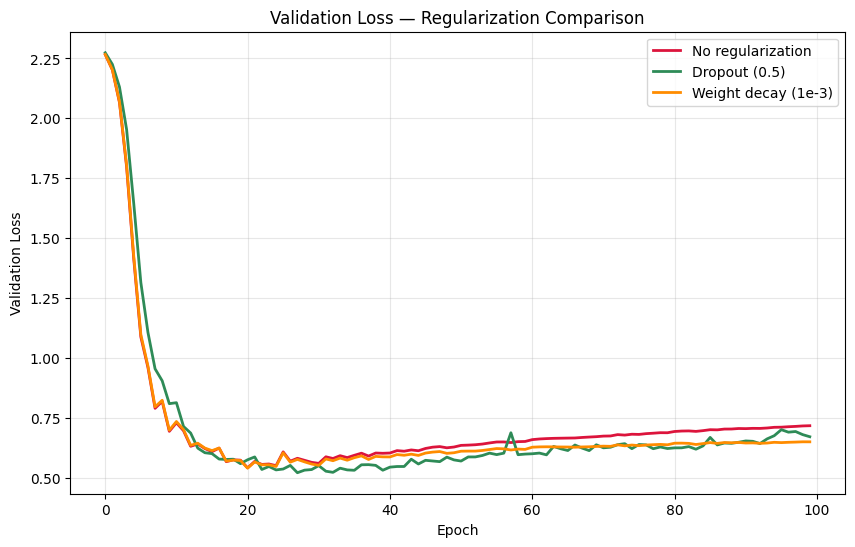

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(plain_val, label='No regularization', color='crimson', lw=2)
plt.plot(drop_val,  label='Dropout (0.5)',     color='seagreen', lw=2)
plt.plot(wd_val,    label='Weight decay (1e-3)', color='darkorange', lw=2)
plt.title('Validation Loss — Regularization Comparison')
plt.xlabel('Epoch'); plt.ylabel('Validation Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---
## 9. Dropout From Scratch (NumPy)

To prove the mechanism isn't magic, here's dropout implemented by hand. Two essential details:

1. **Inverted scaling:** we divide the surviving activations by `(1 - p)`. This keeps the *expected* sum of activations the same whether dropout is on or off, so no adjustment is needed at test time.
2. **Train only:** during training we apply the random mask; at test time we pass activations through unchanged.

This is exactly what `nn.Dropout` does internally.

In [ ]:
def dropout_forward(x, p=0.5, training=True):
    if not training or p == 0:
        return x                              # test time: pass through unchanged
    # Random mask: keep each unit with probability (1 - p)
    mask = (np.random.rand(*x.shape) > p).astype(np.float32)
    return x * mask / (1 - p)                 # apply mask AND scale by 1/(1-p)


# Demo: with many units, the mean activation is preserved thanks to the scaling
np.random.seed(0)
activations = np.ones((1, 10000))
dropped = dropout_forward(activations, p=0.5, training=True)
print(f"Fraction of units kept: {(dropped > 0).mean():.2f}  (expect ~0.50)")
print(f"Mean activation — original: {activations.mean():.3f}, after dropout: {dropped.mean():.3f}  (preserved by 1/(1-p) scaling)")

Fraction of units kept: 0.49  (expect ~0.50)
Mean activation — original: 1.000, after dropout: 0.987  (preserved by 1/(1-p) scaling)


---
## Summary

| Technique | Mechanism | PyTorch |
|---|---|---|
| **Dropout** | randomly zero neurons in training; forces redundancy | `nn.Dropout(p)` + `model.train()/eval()` |
| **Weight decay (L2)** | penalize large weights; prefer simpler functions | `weight_decay=` in optimizer |

**What we saw:**
- A big model on 500 images **overfits** — train loss → 0, validation loss high and rising.
- **Dropout** and **weight decay** both shrink the train/validation gap, trading a little training-set performance for better generalization.
- Dropout must be **off at test time** — handled by `model.eval()`, or by the `1/(1-p)` scaling in the from-scratch version.

**Key intuition:** regularization deliberately handicaps the network during training so it can't memorize — forcing it to learn general patterns that transfer to new data.

**Next: batch normalization from scratch.**